# R-CNN (Region-Based Convolutional Neural Network) Implementation
### Object Detection from Scratch using PyTorch



## Cell 1 — Install Dependencies

In [ ]:
# Install required libraries
!pip install torch torchvision opencv-python-headless matplotlib scikit-learn numpy Pillow tqdm
!pip install selective-search  # lightweight Python selective search

## Cell 2 — Imports & Device Setup

In [27]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu


## Cell 3 — Selective Search Region Proposals

In [28]:
def selective_search_proposals(image_bgr, max_proposals=2000, mode='fast'):
    """
    Run OpenCV Selective Search to generate region proposals.
    
    Args:
        image_bgr   : BGR image (numpy array from cv2.imread)
        max_proposals: maximum number of proposals to return
        mode        : 'fast' or 'quality'
    
    Returns:
        proposals   : list of (x, y, w, h) bounding boxes
    """
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image_bgr)
    if mode == 'fast':
        ss.switchToSelectiveSearchFast()
    else:
        ss.switchToSelectiveSearchQuality()
    
    rects = ss.process()  # returns (x, y, w, h)
    proposals = rects[:max_proposals].tolist()
    print(f'[Selective Search] {len(proposals)} proposals generated')
    return proposals


def compute_iou(boxA, boxB):
    """
    Compute Intersection over Union between two boxes.
    Boxes format: (x, y, w, h)
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    union = areaA + areaB - inter
    return inter / (union + 1e-6)


def label_proposals(proposals, gt_boxes, gt_labels,
                    pos_iou_thresh=0.5, neg_iou_thresh=0.3):
    """
    Assign class labels to proposals based on IoU with ground-truth boxes.
    
    Returns:
        labeled  : list of (proposal, label) — 'background' for negatives
    """
    labeled = []
    for prop in proposals:
        best_iou, best_label = 0.0, 'background'
        for gt_box, gt_label in zip(gt_boxes, gt_labels):
            iou = compute_iou(prop, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_label = gt_label
        if best_iou < neg_iou_thresh:
            best_label = 'background'
        elif best_iou < pos_iou_thresh:
            continue  # ignore ambiguous proposals
        labeled.append((prop, best_label))
    return labeled

print('Selective Search utilities defined.')

Selective Search utilities defined.


## Cell 4 — CNN Feature Extractor (ResNet-50 Backbone)

In [29]:
class RCNNFeatureExtractor(nn.Module):
    """
    ResNet-50 backbone with the classification head removed.
    Outputs a 2048-dim feature vector per region crop.
    """
    def __init__(self, pretrained=True):
        super().__init__()
        backbone = models.resnet50(pretrained=pretrained)
        # Remove avgpool and fc layers — keep conv layers
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.feat_dim = 2048

    def forward(self, x):
        x = self.features(x)   # (B, 2048, H', W')
        x = self.pool(x)       # (B, 2048, 1, 1)
        x = x.flatten(1)       # (B, 2048)
        return x


# Transform applied to each warped region crop (R-CNN warps to 227x227)
RCNN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

feature_extractor = RCNNFeatureExtractor(pretrained=True).to(DEVICE)
feature_extractor.eval()
print(f'Feature extractor ready. Output dim: {feature_extractor.feat_dim}')

Feature extractor ready. Output dim: 2048


## Cell 5 — Region Crop & Feature Extraction Pipeline

In [30]:
def crop_and_warp(image_rgb, box, context_pad=16):
    """
    Crop a region proposal from the image with optional context padding,
    then convert to PIL Image.
    box: (x, y, w, h)
    """
    x, y, w, h = box
    H, W = image_rgb.shape[:2]
    x1 = max(0, x - context_pad)
    y1 = max(0, y - context_pad)
    x2 = min(W, x + w + context_pad)
    y2 = min(H, y + h + context_pad)
    crop = image_rgb[y1:y2, x1:x2]
    return Image.fromarray(crop)


@torch.no_grad()
def extract_features_batch(image_rgb, proposals, batch_size=64):
    """
    Extract CNN features for all proposals in mini-batches.
    
    Returns:
        features: numpy array of shape (N, feat_dim)
    """
    all_feats = []
    for i in tqdm(range(0, len(proposals), batch_size), desc='Extracting features'):
        batch_boxes = proposals[i:i+batch_size]
        tensors = []
        for box in batch_boxes:
            crop = crop_and_warp(image_rgb, box)
            t = RCNN_TRANSFORM(crop)
            tensors.append(t)
        batch = torch.stack(tensors).to(DEVICE)   # (B, 3, 224, 224)
        feats = feature_extractor(batch)           # (B, 2048)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)

print('Feature extraction utilities defined.')

Feature extraction utilities defined.


## Cell 6 — SVM Classifier (per class)

In [31]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


class RCNNClassifier:
    """
    One-vs-rest SVM classifiers for R-CNN.
    One LinearSVC per class (including background).
    """
    def __init__(self, classes):
        self.classes = classes  # list of class names
        self.svms = {}
        for cls in classes:
            self.svms[cls] = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', LinearSVC(C=0.001, max_iter=5000))
            ])

    def train(self, features, labels):
        """
        Train one SVM per class.
        features: (N, D), labels: list of class strings
        """
        labels = np.array(labels)
        for cls in self.classes:
            binary_labels = (labels == cls).astype(int)
            print(f'  Training SVM for class "{cls}" | positives: {binary_labels.sum()}')
            self.svms[cls].fit(features, binary_labels)
        print('All SVMs trained.')

    def predict(self, features):
        """
        For each proposal, return (predicted_class, confidence_score).
        """
        scores = {}
        for cls in self.classes:
            scores[cls] = self.svms[cls].decision_function(features)
        score_matrix = np.stack([scores[c] for c in self.classes], axis=1)
        best_idx = np.argmax(score_matrix, axis=1)
        predictions = [(self.classes[i], score_matrix[n, i])
                       for n, i in enumerate(best_idx)]
        return predictions

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f'Classifier saved to {path}')

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)

print('RCNNClassifier defined.')

RCNNClassifier defined.


## Cell 7 — Bounding Box Regression

In [32]:
from sklearn.linear_model import Ridge


def xywh_to_targets(proposal, gt_box):
    """
    Compute regression targets (tx, ty, tw, th) as in the R-CNN paper.
    """
    px, py, pw, ph = proposal
    gx, gy, gw, gh = gt_box
    cx_p, cy_p = px + pw/2, py + ph/2
    cx_g, cy_g = gx + gw/2, gy + gh/2
    tx = (cx_g - cx_p) / pw
    ty = (cy_g - cy_p) / ph
    tw = np.log(gw / (pw + 1e-6))
    th = np.log(gh / (ph + 1e-6))
    return np.array([tx, ty, tw, th])


def apply_bbox_deltas(proposal, deltas):
    """
    Apply predicted regression deltas to a proposal box.
    Returns adjusted (x, y, w, h).
    """
    px, py, pw, ph = proposal
    tx, ty, tw, th = deltas
    cx = px + pw/2 + tx * pw
    cy = py + ph/2 + ty * ph
    nw = pw * np.exp(tw)
    nh = ph * np.exp(th)
    return (cx - nw/2, cy - nh/2, nw, nh)


class BBoxRegressor:
    """
    Separate Ridge regressor per class to refine bounding boxes.
    """
    def __init__(self, classes):
        self.regressors = {cls: Ridge(alpha=1.0) for cls in classes}

    def train(self, features_per_class, targets_per_class):
        for cls, feats in features_per_class.items():
            targets = np.stack(targets_per_class[cls])
            print(f'  Training bbox regressor for "{cls}" with {len(feats)} samples')
            self.regressors[cls].fit(feats, targets)
        print('All bbox regressors trained.')

    def predict(self, cls, features):
        return self.regressors[cls].predict(features)

print('Bounding box regression utilities defined.')

Bounding box regression utilities defined.


## Cell 8 — Non-Maximum Suppression (NMS)

In [33]:
def non_maximum_suppression(boxes, scores, iou_threshold=0.3):
    """
    Greedy NMS to suppress overlapping detections.
    
    Args:
        boxes         : list of (x, y, w, h)
        scores        : confidence scores (higher = better)
        iou_threshold : suppress if IoU > threshold
    
    Returns:
        keep_indices  : indices of surviving boxes
    """
    if len(boxes) == 0:
        return []
    
    boxes  = np.array(boxes, dtype=float)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]  # descending confidence
    keep   = []

    while order.size > 0:
        i = order[0]
        keep.append(i)
        rest  = order[1:]
        ious  = np.array([compute_iou(boxes[i], boxes[j]) for j in rest])
        order = rest[ious <= iou_threshold]

    return keep

print('NMS defined.')

NMS defined.


## Cell 9 — Full R-CNN Inference Pipeline

In [34]:
def rcnn_detect(image_path, classifier, bbox_regressor,
                score_thresh=0.5, nms_iou=0.3, max_proposals=500):
    """
    Full R-CNN inference on a single image.

    Steps:
      1. Selective Search  -> region proposals
      2. Warp & CNN        -> feature vectors
      3. SVM               -> class + score per proposal
      4. BBox regressor    -> refined boxes
      5. NMS               -> final detections

    Returns:
        detections: list of {'box': (x,y,w,h), 'label': str, 'score': float}
    """
    # Load image
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Step 1: Region Proposals
    proposals = selective_search_proposals(image_bgr, max_proposals=max_proposals)

    # Step 2: Feature Extraction
    features = extract_features_batch(image_rgb, proposals)

    # Step 3: SVM Classification
    predictions = classifier.predict(features)

    # Step 4: BBox Regression + Thresholding
    detections_by_class = {}
    for i, (label, score) in enumerate(predictions):
        if label == 'background' or score < score_thresh:
            continue
        feats = features[i:i+1]
        deltas = bbox_regressor.predict(label, feats)[0]
        refined_box = apply_bbox_deltas(proposals[i], deltas)
        detections_by_class.setdefault(label, {'boxes': [], 'scores': []})
        detections_by_class[label]['boxes'].append(refined_box)
        detections_by_class[label]['scores'].append(score)

    # Step 5: NMS per class
    final_detections = []
    for label, data in detections_by_class.items():
        keep = non_maximum_suppression(data['boxes'], data['scores'], nms_iou)
        for idx in keep:
            final_detections.append({
                'box':   data['boxes'][idx],
                'label': label,
                'score': data['scores'][idx]
            })

    print(f'[RCNN] {len(final_detections)} detections after NMS')
    return image_rgb, final_detections

print('R-CNN inference pipeline defined.')

R-CNN inference pipeline defined.


## Cell 10 — Visualise Detections

In [35]:
COLORS = plt.cm.Set1.colors  # 9 distinct colors

def visualize_detections(image_rgb, detections, title='R-CNN Detections'):
    """
    Draw bounding boxes and labels on the image.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image_rgb)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    unique_labels = list({d['label'] for d in detections})
    label_color   = {lbl: COLORS[i % len(COLORS)] for i, lbl in enumerate(unique_labels)}

    for det in detections:
        x, y, w, h = det['box']
        lbl, score = det['label'], det['score']
        color = label_color[lbl]
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"{lbl}: {score:.2f}",
                fontsize=10, color='white',
                bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none'))

    plt.tight_layout()
    plt.show()
    print(f'Displayed {len(detections)} detections.')

print('Visualization utilities defined.')

Visualization utilities defined.


## Cell 11 — Toy Training Demo (Synthetic Data)
Because training R-CNN on PASCAL VOC requires ~10 GB of data, this cell demonstrates
the training loop using randomly generated features & labels so you can verify the
pipeline end-to-end without a dataset download.

In [36]:
np.random.seed(42)
CLASSES = ['cat', 'dog', 'background']
N_TRAIN  = 600   # total fake proposals
FEAT_DIM = 2048  # matches ResNet-50 output

# Generate random features
fake_features = np.random.randn(N_TRAIN, FEAT_DIM).astype(np.float32)

# Generate random labels (balanced)
fake_labels = np.array(CLASSES * (N_TRAIN // len(CLASSES)) +
                        CLASSES[:N_TRAIN % len(CLASSES)])
np.random.shuffle(fake_labels)

# ---- Train Classifier ----
print('Training SVM classifiers...')
clf = RCNNClassifier(classes=CLASSES)
clf.train(fake_features, fake_labels)

# ---- Train BBox Regressors ----
print('\nTraining BBox regressors...')
features_per_class = {c: [] for c in CLASSES}
targets_per_class  = {c: [] for c in CLASSES}

for i, lbl in enumerate(fake_labels):
    features_per_class[lbl].append(fake_features[i])
    targets_per_class[lbl].append(np.random.randn(4) * 0.1)  # small fake deltas

# Convert to arrays
for c in CLASSES:
    features_per_class[c] = np.stack(features_per_class[c])

bbox_reg = BBoxRegressor(classes=CLASSES)
bbox_reg.train(features_per_class, targets_per_class)

print('\n✅ Toy training complete.')

Training SVM classifiers...
  Training SVM for class "cat" | positives: 200
  Training SVM for class "dog" | positives: 200
  Training SVM for class "background" | positives: 200
All SVMs trained.

Training BBox regressors...
  Training bbox regressor for "cat" with 200 samples
  Training bbox regressor for "dog" with 200 samples
  Training bbox regressor for "background" with 200 samples
All bbox regressors trained.

✅ Toy training complete.


## Cell 12 — Save / Load Trained Models

In [37]:
import os
os.makedirs('rcnn_weights', exist_ok=True)

# Save
clf.save('rcnn_weights/svm_classifier.pkl')
with open('rcnn_weights/bbox_regressor.pkl', 'wb') as f:
    pickle.dump(bbox_reg, f)
print('Models saved.')

# Load back
loaded_clf = RCNNClassifier.load('rcnn_weights/svm_classifier.pkl')
with open('rcnn_weights/bbox_regressor.pkl', 'rb') as f:
    loaded_bbox_reg = pickle.load(f)
print('Models loaded successfully.')

Classifier saved to rcnn_weights/svm_classifier.pkl
Models saved.
Models loaded successfully.


## Cell 13 — End-to-End Test on a Sample Image

Downloaded sample image to dog.jpg
[Selective Search] 100 proposals generated


Extracting features: 100%|██████████| 2/2 [00:15<00:00,  7.52s/it]


[RCNN] 17 detections after NMS


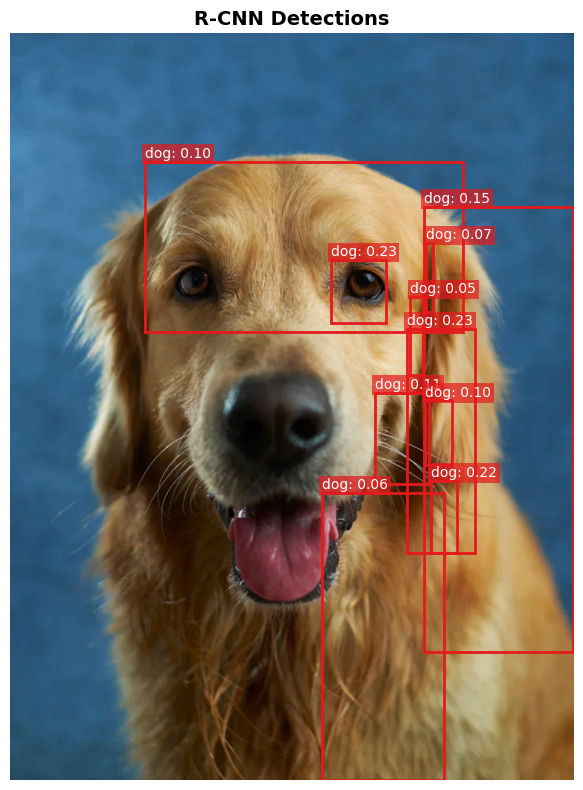

Displayed 10 detections.


In [39]:
import urllib.request

# Download a sample image if you have no local image
SAMPLE_URL = 'https://www.leadingdog.co.uk/cdn/shop/articles/photo-1558788353-f76d92427f16_c730e7ea-b021-48d5-80f4-a4290874a938.webp?v=1762947704&width=800'
SAMPLE_PATH = 'dog.jpg'

if not os.path.exists(SAMPLE_PATH):
    urllib.request.urlretrieve(SAMPLE_URL, SAMPLE_PATH)
    print(f'Downloaded sample image to {SAMPLE_PATH}')

# Run full R-CNN inference
image_rgb, detections = rcnn_detect(
    image_path      = SAMPLE_PATH,
    classifier      = loaded_clf,
    bbox_regressor  = loaded_bbox_reg,
    score_thresh    = 0.0,   # set low for toy demo — real threshold: 0.5
    nms_iou         = 0.3,
    max_proposals   = 100
)

visualize_detections(image_rgb, detections[:10])  # show top-10

## Cell 14 — (Optional) PASCAL VOC Data Loader for Real Training

In [17]:
# Uncomment & run to download PASCAL VOC 2007 (~870 MB)
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtrainval_06-Nov-2007.tar

import xml.etree.ElementTree as ET

class VOCDataset:
    """
    Minimal PASCAL VOC loader to collect
    (image_path, gt_boxes, gt_labels) triples.
    Set `voc_root` to the extracted VOCdevkit/VOC2007 folder.
    """
    def __init__(self, voc_root, split='train'):
        self.voc_root = voc_root
        img_set_file = os.path.join(voc_root, 'ImageSets', 'Main', f'{split}.txt')
        with open(img_set_file) as f:
            self.ids = [l.strip() for l in f]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_path = os.path.join(self.voc_root, 'JPEGImages', f'{img_id}.jpg')
        ann_path = os.path.join(self.voc_root, 'Annotations', f'{img_id}.xml')
        tree = ET.parse(ann_path)
        root = tree.getroot()
        gt_boxes, gt_labels = [], []
        for obj in root.findall('object'):
            label = obj.find('name').text
            bnd   = obj.find('bndbox')
            x1 = int(bnd.find('xmin').text)
            y1 = int(bnd.find('ymin').text)
            x2 = int(bnd.find('xmax').text)
            y2 = int(bnd.find('ymax').text)
            gt_boxes.append((x1, y1, x2-x1, y2-y1))  # xywh
            gt_labels.append(label)
        return img_path, gt_boxes, gt_labels

# Example usage:
ds = VOCDataset('VOCdevkit/VOC2007', split='train')
img_path, gt_boxes, gt_labels = ds[0]
print('VOC data loader ready (uncomment download lines to use).')

--2026-05-29 16:39:20--  http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-05-29 16:39:20--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-05-29 16:39:20--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving thor.robots.ox.ac.uk (thor.ro